In [2]:
!pip install -U transformers

In [3]:
!pip install transformer_lens

In [3]:
#version mismatch between torchaudio and torch -> Re-install torchaudio
!pip uninstall -y torchaudio
!pip install torchaudio==2.7.1

Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 25.1 MB/s eta 0:00:00


In [4]:
import torch
import transformers
import torchaudio

print(torchaudio.__version__)
print(torch.__version__)
print(transformers.__version__)

2.7.1+cu126
2.7.1+cu126
5.12.1


**The succinctly/text2image-prompt-generator model is based on the GPT-2 architecture and contains 12 transformer layers, 12 attention heads, a hidden dimension of 768, and an MLP dimension of 3072, with a context length of 1024 tokens. It has a vocabulary size of 50,257 tokens**


In [6]:
from transformers import AutoModelForCausalLM
from transformer_lens import HookedTransformer

#Load the pretrained model from Hugging Face.
hf_model = AutoModelForCausalLM.from_pretrained("succinctly/text2image-prompt-generator")

#Convert to TransformerLens format
model = HookedTransformer.from_pretrained("gpt2",hf_model=hf_model)

#Model Configuration
print(model.cfg)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'NTK_original_ctx_len': 8192,
 'act_fn': 'gelu_new',
 'attention_dir': 'causal',
 'attn_only': False,
 'attn_scale': np.float64(8.0),
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 64,
 'd_mlp': 3072,
 'd_model': 768,
 'd_vocab': 50257,
 'd_vocab_out': 50257,
 'decoder_start_token_id': None,
 'default_prepend_bos': True,
 'device': 'cuda',
 'dtype': torch.float32,
 'eps': 1e-05,
 'experts_per_token': None,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': False,
 'initializer_range': np.float64(0.02886751345948129),
 'layer_norm_folding': False,
 'load_in_4bit': False,
 'model_name': 'gpt2',
 'n_ctx': 1024,
 'n_devices': 1,
 'n_heads': 12,
 'n_key_

In [7]:
clean_prompt = "A futuristic cyberpunk city at night with neon lights"
corrupt_prompt = "A medieval fantasy village during the day with wooden houses"

clean_logits, clean_cache = model.run_with_cache(clean_prompt)
corrupt_logits, corrupt_cache = model.run_with_cache(corrupt_prompt)

#Shape of logits
print(clean_logits.shape)
print(corrupt_logits.shape)

#Tokenize the inputs
print(model.to_str_tokens(clean_prompt))
print(model.to_str_tokens(corrupt_prompt))

torch.Size([1, 11, 50257])
torch.Size([1, 11, 50257])
['<|endoftext|>', 'A', ' futuristic', ' cyber', 'punk', ' city', ' at', ' night', ' with', ' neon', ' lights']
['<|endoftext|>', 'A', ' medieval', ' fantasy', ' village', ' during', ' the', ' day', ' with', ' wooden', ' houses']


**Here we check how much the residual stream differs between the clean and corrupt prompts at each transformer layer. Increasing divergence across layers suggests that the model gradually builds distinct representations of the two visual scenes. Peaks in later layers indicate where high-level visual attributes and scene semantics become strongly encoded.**

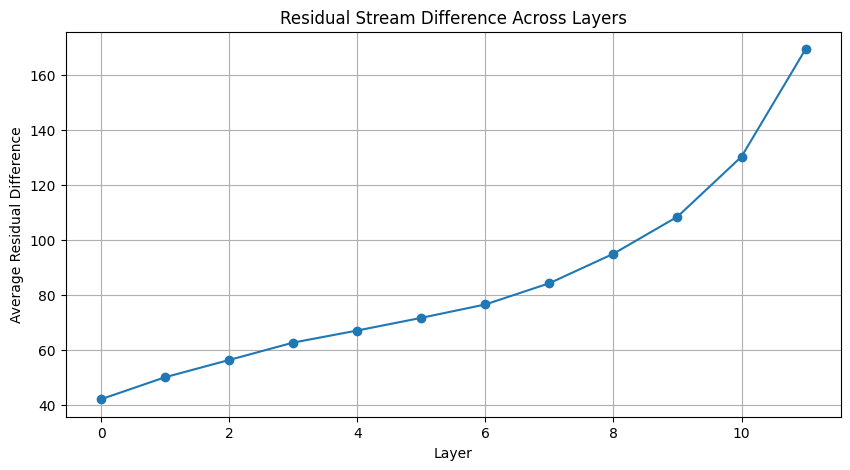

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

layer_diffs = []

for layer in range(model.cfg.n_layers):

    #Get residual stream at a specific layer
    clean_resid = clean_cache["resid_post", layer]
    corrupt_resid = corrupt_cache["resid_post", layer]

    #Normalize the difference between the two residual streams
    diff = torch.norm(clean_resid - corrupt_resid,dim=-1).mean()

    layer_diffs.append(diff.item())

'''
In the plot
Early layers (0–4) show modest separation between the two prompts.
Middle layers (5–8) gradually amplify the difference.
Late layers (9–11) show a sharp increase in residual divergence.
Layer 11 has the largest difference, suggesting that scene-level visual concepts are consolidated near the end of the network.
'''

plt.figure(figsize=(10,5))
plt.plot(layer_diffs, marker='o')
plt.xlabel("Layer")
plt.ylabel("Average Residual Difference")
plt.title("Residual Stream Difference Across Layers")
plt.grid(True)
plt.show()

**The Layer × Token Position heatmap reveals that representational differences between the clean and corrupt prompts increase progressively across the transformer layers, with the strongest divergence occurring in the final layers (Layers 10–11). Tokens corresponding to scene-defining visual attributes such as "cyber", "punk", "city", and "neon" exhibit the highest activation differences, indicating that these descriptors play a major role in encoding visual metadata. In contrast, generic structural tokens such as "A" and "<end of text" remain largely unchanged throughout the network.**

/tmp/ipykernel_8340/666379504.py:23: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  heatmap_data = torch.tensor(heatmap_data)


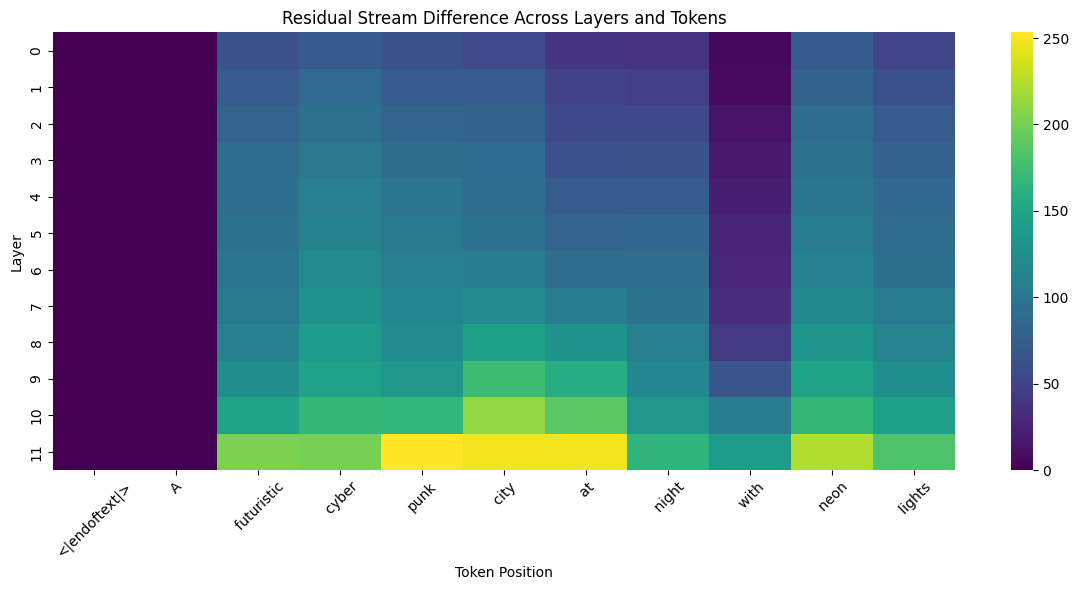

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

n_layers = model.cfg.n_layers
tokens = model.to_str_tokens(clean_prompt)

# Store residual differences for every layer and token position
heatmap_data = []

for layer in range(n_layers):

    clean_resid = clean_cache["resid_post", layer][0]
    corrupt_resid = corrupt_cache["resid_post", layer][0]

    # Difference magnitude for each token
    diff = torch.norm(
        clean_resid - corrupt_resid,
        dim=-1
    )

    heatmap_data.append(diff.cpu().numpy())

heatmap_data = torch.tensor(heatmap_data)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="viridis",
    xticklabels=tokens,
    yticklabels=range(n_layers)
)

plt.xlabel("Token Position")
plt.ylabel("Layer")
plt.title("Residual Stream Difference Across Layers and Tokens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
import circuitsvis as cv
from IPython.display import display

# Top heads from our heatmap
important_heads = [
    (11, 0),
    (11, 3),
    (11, 8),
    (11, 11)
]

tokens = model.to_str_tokens(clean_prompt)

for layer, head in important_heads:

    print(f"\nLayer {layer} Head {head}")

    display(
        cv.attention.attention_patterns(
            attention=clean_cache["pattern", layer][0, head],
            tokens=tokens
        )
    )


Layer 11 Head 0



Layer 11 Head 3



Layer 11 Head 8



Layer 11 Head 11


**The concentration of high-scoring heads in the final layers indicates that visual scene information is not distributed uniformly across the network. Instead, the transformer appears to consolidate scene-specific representations into a small number of specialized attention heads. These heads are likely responsible for integrating descriptors such as "cyberpunk", "city", and "neon" into a coherent visual representation before next-token generation.**

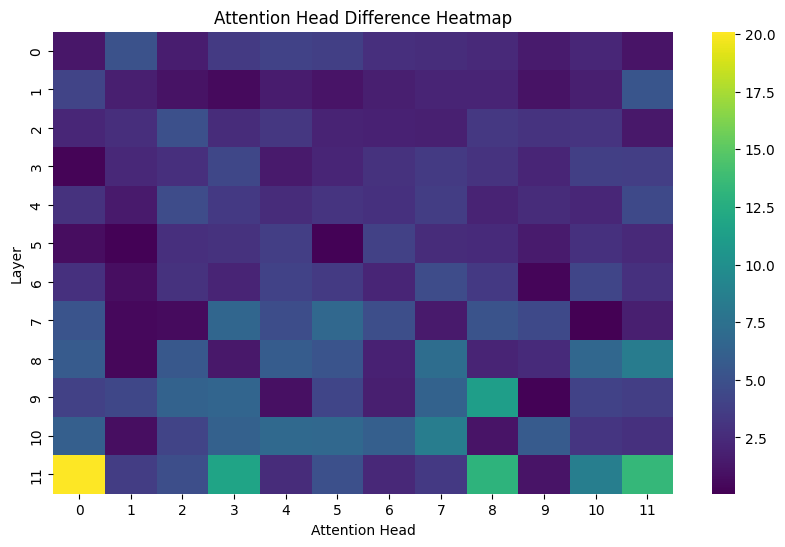

In [18]:
# Enable caching of attention head outputs
model.set_use_attn_result(True)

# Recompute caches
clean_logits, clean_cache = model.run_with_cache(clean_prompt)
corrupt_logits, corrupt_cache = model.run_with_cache(corrupt_prompt)

#Determine Model Size
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads

#Store one score per attention head
head_scores = torch.zeros(n_layers, n_heads)

for layer in range(n_layers):

    #Extract Head Outputs
    attn_result_clean = clean_cache["result", layer][0]
    attn_result_corrupt = corrupt_cache["result", layer][0]

    for head in range(n_heads):

        diff = torch.norm(attn_result_clean[:, head, :] -attn_result_corrupt[:, head, :],dim=-1).mean()

        head_scores[layer, head] = diff

plt.figure(figsize=(10,6))

sns.heatmap(head_scores.cpu(),cmap="viridis")

plt.xlabel("Attention Head")
plt.ylabel("Layer")
plt.title("Attention Head Difference Heatmap")
plt.show()

**Residual stream activation patching was performed by replacing individual residual activations from the clean prompt into the corrupt prompt and measuring the resulting change in the model's output representation. The resulting heatmap identifies token-layer pairs that are causally important for encoding visual scene information. The strongest effects were observed for the tokens "city", "cyber", "punk", and "neon", indicating that these descriptors play a central role in shaping the model's internal visual representation. In contrast, generic tokens such as "A" and "<|endoftext|>" produced negligible effects, demonstrating that visual metadata is concentrated in semantically meaningful scene descriptors.**

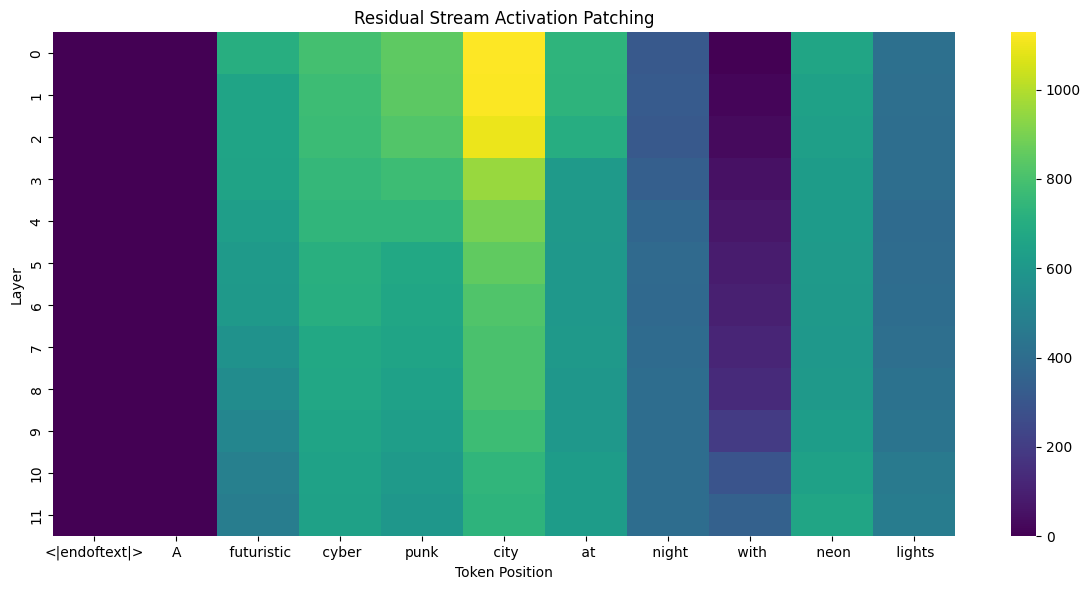

In [25]:
from functools import partial
import torch

def patch_residual_stream(corrupted_activation,hook,clean_cache,pos):
    corrupted_activation[:, pos, :] = clean_cache[hook.name][:, pos, :]

    return corrupted_activation


patching_scores = torch.zeros(
    model.cfg.n_layers,
    len(model.to_str_tokens(clean_prompt))
)

for layer in range(model.cfg.n_layers):

    for pos in range(len(model.to_str_tokens(clean_prompt))):

        patched_logits = model.run_with_hooks(
            corrupt_prompt,
            fwd_hooks=[(f"blocks.{layer}.hook_resid_pre",partial(patch_residual_stream,clean_cache=clean_cache,pos=pos))])

        # Compare logits instead of caching again
        final_diff = torch.norm(patched_logits -corrupt_logits)

        patching_scores[layer, pos] = final_diff.item()

plt.figure(figsize=(12,6))

sns.heatmap(
    patching_scores.cpu(),
    cmap="viridis",
    xticklabels=model.to_str_tokens(clean_prompt)
)

plt.xlabel("Token Position")
plt.ylabel("Layer")
plt.title("Residual Stream Activation Patching")
plt.tight_layout()
plt.show()

**Residual dimension analysis was performed by comparing the residual stream representations of the cyberpunk and medieval prompts at each layer. The resulting heatmap reveals that only a subset of residual dimensions exhibit strong activation differences, particularly in the final layers of the network. This suggests that visual metadata is encoded within specific directions of the residual stream rather than being uniformly distributed across all dimensions.**

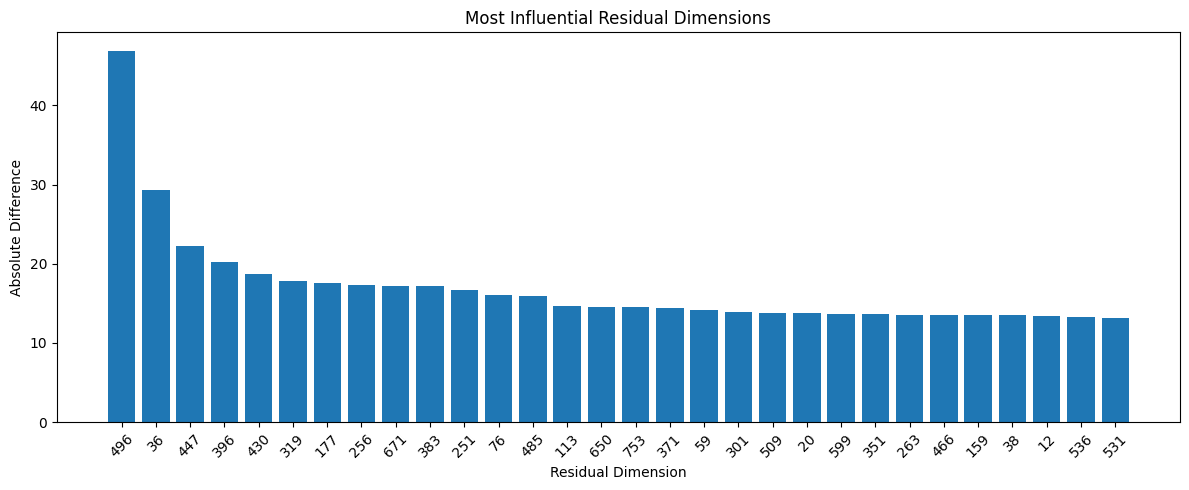

In [28]:
final_layer = model.cfg.n_layers - 1

clean_final = clean_cache["resid_post", final_layer][0, -1]
corrupt_final = corrupt_cache["resid_post", final_layer][0, -1]

# Dimension-wise difference
residual_diff = (clean_final - corrupt_final).abs()

# Top 30 dimensions
topk = torch.topk(residual_diff, k=30)

plt.figure(figsize=(12,5))

plt.bar(
    range(30),
    topk.values.cpu()
)

plt.xticks(
    range(30),
    topk.indices.cpu().numpy(),
    rotation=45
)

plt.xlabel("Residual Dimension")
plt.ylabel("Absolute Difference")
plt.title("Most Influential Residual Dimensions")
plt.tight_layout()
plt.show()